In [1]:
# path = '/scratch/ps9044/newsetting/PubMedQA10_BeaverTails3_1.00_1.00_1.00_1.00_1.00_1.00_1.00_0.50_0.50_0.50_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20260217161005'
# path = '/scratch/ps9044/newsetting/PubMedQA10_BeaverTails3_1.00_1.00_1.00_1.00_1.00_1.00_1.00_0.50_0.50_0.50_500_safe_lora_c10s10_i10_b16a1_l512_r32a64_20260217161028'
# path = '/scratch/ps9044/newsetting/PubMedQA10_BeaverTails4_1.00_1.00_1.00_1.00_1.00_1.00_0.50_0.50_0.50_0.50_500_safe_lora_c10s10_i10_b16a1_l512_r32a64_20260217192731'
# path = '/scratch/ps9044/newsetting/PubMedQA10_BeaverTails4_1.00_1.00_1.00_1.00_1.00_1.00_0.50_0.50_0.50_0.50_500_safe_lora_c10s10_i10_b16a1_l512_r32a64_20260217192731'
# path = '/scratch/ps9044/newsetting/PubMedQA7_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_fedavg_c7s10_i10_b16a1_l512_r32a64_20260218140241'
# path = '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_500_foolsgold_c10s10_i10_b16a1_l512_r32a64_20260226102318'
# path = '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_mixture_analytical_c7s7_i10_b16a1_l512_r32a64_20260301190953'
path = '/scratch/ps9044/aaai2026/Llama-3.1-8B-Instruct_PubMedQA_medQA_emrqa_cord19_expguardtrain3_1.00_1.00_1.00_1.00_1.00_1.00_1.00_0.50_0.50_0.50_500_safelorav2data_c10s10_i10_b16a1_l512_r32a64_20260706213428'
import os
import json
with open(os.path.join(path, 'dirichlet_alloc.json'), 'r') as f:
    data = json.load(f)



In [2]:
data

[[0, 513, 265, 4],
 [564, 26, 5, 538],
 [0, 534, 100, 36],
 [16, 2, 5, 2],
 [0, 102, 87, 612],
 [3, 10, 41, 0],
 [18, 36, 12, 0],
 [609, 0, 242, 30],
 [40, 27, 108, 9],
 [0, 0, 385, 19]]

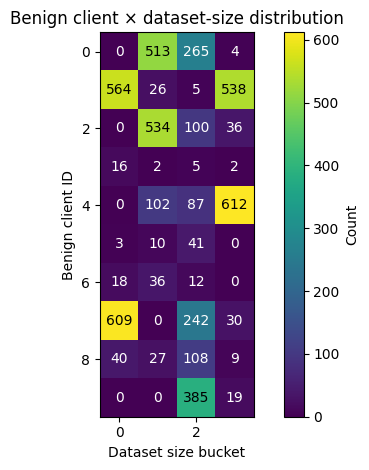

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
data = np.array(data)

plt.figure()
im = plt.imshow(data)
plt.colorbar(im, label="Count")

plt.title("Benign client × dataset-size distribution")
plt.xlabel("Dataset size bucket")
plt.ylabel("Benign client ID")

# annotate cells
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        color = 'w' if data[i, j] < data.max() / 2 else 'k'
        plt.text(j, i, str(data[i, j]), ha="center", va="center", color=color)

plt.tight_layout()
plt.show()

In [5]:
import os
import json

files = [
    '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_500_foolsgoldbenign_c10s10_i10_b16a1_l512_r32a64_20260510163750',
    '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_500_foolsgoldbenign_c10s10_i10_b16a1_l512_r32a64_20260510163806',
    '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_500_foolsgoldbenign_c10s10_i10_b16a1_l512_r32a64_20260510163825',
    '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_500_foolsgoldbenign_c10s10_i10_b16a1_l512_r32a64_20260510163838',
    '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_500_foolsgoldbenign_c10s10_i10_b16a1_l512_r32a64_20260510163916'
]

files = [
    '/scratch/ps9044_copy_copy/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_500_foolsgold_c10s10_i10_b16a1_l512_r32a64_20260416005052',
    '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_500_foolsgold_c10s10_i10_b16a1_l512_r32a64_20260424113956',
    '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_500_foolsgold_c10s10_i10_b16a1_l512_r32a64_20260424143308',
    '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_500_foolsgold_c10s10_i10_b16a1_l512_r32a64_20260429104019',
    '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_500_foolsgold_c10s10_i10_b16a1_l512_r32a64_20260429210148',
]

# Header
print("file_idx\tround\t" + "\t".join([f"weight_{i}" for i in range(10)]))

for file_idx, file in enumerate(files):
    for round_num in range(30):
        path = os.path.join(file, f'foolsgold/round_{round_num}.json')

        with open(path) as f:
            data = json.load(f)

        weights = data["client_weights"]

        row = [file_idx, round_num] + weights
        print("\t".join(map(str, row)))

file_idx	round	weight_0	weight_1	weight_2	weight_3	weight_4	weight_5	weight_6	weight_7	weight_8	weight_9
0	0	1.0	1.0	0.0	0.32406532764434814	1.0	0.0	1.0	0.2821592688560486	0.471456915140152	0.2821592688560486
0	1	1.0	1.0	1.0	0.0	1.0	0.0	1.0	0.43833300471305847	0.43833300471305847	0.4560237228870392
0	2	1.0	1.0	1.0	1.0	1.0	1.0	1.0	0.027981817722320557	0.027981817722320557	0.04245901107788086
0	3	1.0	0.0	1.0	1.0	0.0	1.0	0.6717156171798706	0.0	0.0	0.0
0	4	1.0	0.39483585953712463	1.0	1.0	0.39483585953712463	1.0	1.0	0.0	0.0	0.0
0	5	1.0	1.0	1.0	1.0	1.0	1.0	1.0	0.0	0.0	0.0
0	6	1.0	1.0	1.0	1.0	1.0	1.0	1.0	0.0	0.0	0.0
0	7	1.0	1.0	1.0	1.0	1.0	1.0	1.0	0.0	0.0	0.0
0	8	1.0	1.0	1.0	1.0	1.0	1.0	1.0	0.0	0.0	0.0
0	9	1.0	1.0	1.0	1.0	1.0	1.0	1.0	0.0	0.0	0.0
0	10	1.0	1.0	1.0	1.0	1.0	1.0	1.0	0.0	0.0	0.0
0	11	1.0	1.0	1.0	1.0	1.0	1.0	1.0	0.0	0.0	0.0
0	12	1.0	1.0	1.0	1.0	1.0	1.0	1.0	0.0	0.0	0.019489377737045288
0	13	1.0	1.0	1.0	1.0	1.0	1.0	1.0	0.0	0.0	0.0
0	14	1.0	1.0	1.0	1.0	1.0	1.0	1.0	0.0	0.0	0.0
0	15	1.0	

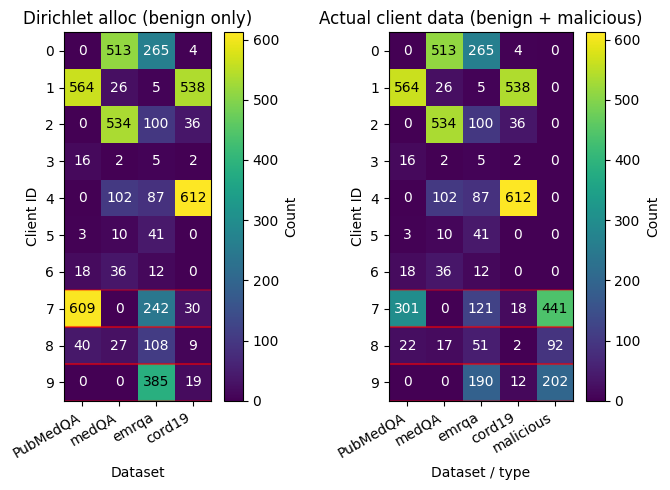

Saved: /home/ps9044/RPA/fedllm-attack/notebooks_final/Llama-3.1-8B-Instruct_PubMedQA_medQA_emrqa_cord19_expguardtrain3_1.00_1.00_1.00_1.00_1.00_1.00_1.00_0.50_0.50_0.50_500_safelorav2data_c10s10_i10_b16a1_l512_r32a64_20260706213428_client_data_distribution_heatmap.png


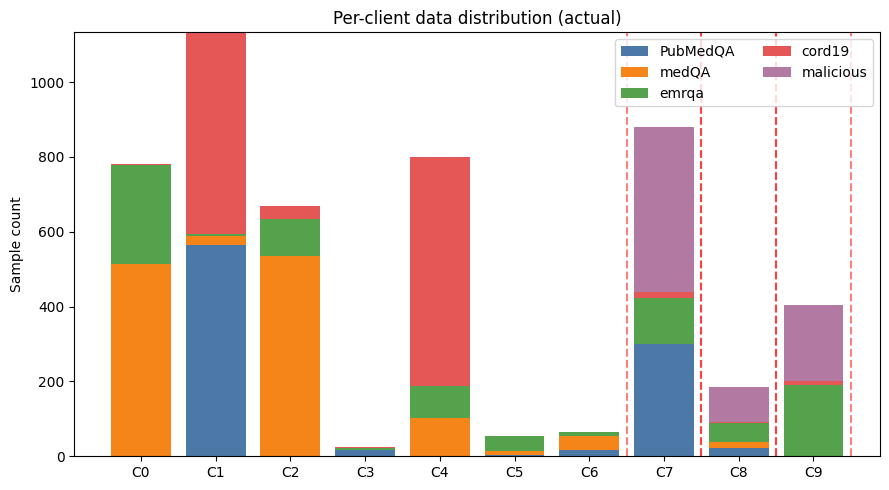

Saved: /home/ps9044/RPA/fedllm-attack/notebooks_final/Llama-3.1-8B-Instruct_PubMedQA_medQA_emrqa_cord19_expguardtrain3_1.00_1.00_1.00_1.00_1.00_1.00_1.00_0.50_0.50_0.50_500_safelorav2data_c10s10_i10_b16a1_l512_r32a64_20260706213428_client_data_distribution_stacked.png
Malicious clients: [7, 8, 9]


In [7]:
import numpy as np
import matplotlib.pyplot as plt

SOURCE_ALIASES = {
    "qiaojin/PubMedQA": "PubMedQA",
    "expguardtrain": "malicious",
}
BENIGN_COLS = ["PubMedQA", "medQA", "emrqa", "cord19"]
COLS = BENIGN_COLS + ["malicious"]

with open(os.path.join(path, "client_data_summary.json")) as f:
    summaries = json.load(f)

with open(os.path.join(path, "dirichlet_alloc.json")) as f:
    dirichlet = np.array(json.load(f))

def normalize_source(name):
    return SOURCE_ALIASES.get(name, name)

def annotate_heatmap(ax, data):
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            color = "w" if data[i, j] < data.max() / 2 else "k"
            ax.text(j, i, str(data[i, j]), ha="center", va="center", color=color)

actual = np.zeros((len(summaries), len(COLS)), dtype=int)
malicious_clients = []
for i, client in enumerate(summaries):
    benign = {normalize_source(k): v for k, v in client["benign_by_source"].items()}
    for j, col in enumerate(BENIGN_COLS):
        actual[i, j] = benign.get(col, 0)
    actual[i, -1] = client["malicious_total"]
    if client["malicious_total"] > 0:
        malicious_clients.append(client["client_id"])

fig, axes = plt.subplots(1, 2, figsize=(7, 5))

im0 = axes[0].imshow(dirichlet)
axes[0].set_title("Dirichlet alloc (benign only)")
axes[0].set_xlabel("Dataset")
axes[0].set_ylabel("Client ID")
axes[0].set_xticks(range(len(BENIGN_COLS)))
axes[0].set_xticklabels(BENIGN_COLS, rotation=30, ha="right")
axes[0].set_yticks(range(len(summaries)))
axes[0].set_yticklabels([c["client_id"] for c in summaries])
plt.colorbar(im0, ax=axes[0], label="Count")
annotate_heatmap(axes[0], dirichlet)

im1 = axes[1].imshow(actual)
axes[1].set_title("Actual client data (benign + malicious)")
axes[1].set_xlabel("Dataset / type")
axes[1].set_ylabel("Client ID")
axes[1].set_xticks(range(len(COLS)))
axes[1].set_xticklabels(COLS, rotation=30, ha="right")
axes[1].set_yticks(range(len(summaries)))
axes[1].set_yticklabels([c["client_id"] for c in summaries])
plt.colorbar(im1, ax=axes[1], label="Count")
annotate_heatmap(axes[1], actual)

for cid in malicious_clients:
    for ax in axes:
        ax.axhline(cid - 0.5, color="red", linewidth=1.5, alpha=0.35)
        ax.axhline(cid + 0.5, color="red", linewidth=1.5, alpha=0.35)

plt.tight_layout()
out_dir = os.path.join(os.path.dirname(os.getcwd()), "notebooks_final")
os.makedirs(out_dir, exist_ok=True)
run_name = os.path.basename(path.rstrip("/"))
out_heatmap = os.path.join(out_dir, f"{run_name}_client_data_distribution_heatmap.png")
plt.savefig(out_heatmap, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_heatmap}")

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(summaries))
bottom = np.zeros(len(summaries))
colors = {
    "PubMedQA": "#4C78A8",
    "medQA": "#F58518",
    "emrqa": "#54A24B",
    "cord19": "#E45756",
    "malicious": "#B279A2",
}
for j, col in enumerate(COLS):
    ax.bar(x, actual[:, j], bottom=bottom, label=col, color=colors[col])
    bottom += actual[:, j]

ax.set_xticks(x)
ax.set_xticklabels([f"C{c['client_id']}" for c in summaries])
ax.set_ylabel("Sample count")
ax.set_title("Per-client data distribution (actual)")
ax.legend(loc="upper right", ncol=2)
for cid in malicious_clients:
    ax.axvline(cid - 0.5, color="red", linestyle="--", alpha=0.5)
    ax.axvline(cid + 0.5, color="red", linestyle="--", alpha=0.5)

plt.tight_layout()
out_bar = os.path.join(out_dir, f"{run_name}_client_data_distribution_stacked.png")
plt.savefig(out_bar, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_bar}")
print(f"Malicious clients: {malicious_clients}")